In [1]:
import pandas as pd

triazine_df = pd.read_csv("../data/virtual_triazines_filtered.csv")

In [2]:
from rdkit import Chem

# Pattern: triazine ring carbon attached to phenyl with ortho-OH
# This matches your T3-type chelating arrangement
chelation_smarts = 'c1nnc(nc1)-c1ccccc1O'

chelation_pattern = Chem.MolFromSmarts(chelation_smarts)

def has_chelation_motif(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return mol.HasSubstructMatch(chelation_pattern)

triazine_df['Has_Chelation_Motif'] = triazine_df['SMILES'].apply(has_chelation_motif)

print(triazine_df['Has_Chelation_Motif'].value_counts())

Has_Chelation_Motif
False    4920
True      119
Name: count, dtype: int64


In [4]:
import numpy as np

def calculate_sensing_score(row):
    score = 0
    
    # Chelation motif is most important — big bonus
    if row['Has_Chelation_Motif']:
        score += 40
    
    # More donor atoms = better coordination (HBA)
    score += row['HBA'] * 5
    
    # H-bond donors needed for deprotonation/binding
    score += row['HBD'] * 8
    
    # Higher TPSA = more exposed donor atoms
    score += (row['TPSA'] / 10)
    
    # Lower LogP = better solution behavior (penalize high LogP)
    score -= row['LogP'] * 2
    
    # More aromatic rings = better fluorescence signal
    score += row['AromaticRings'] * 3
    
    return score

triazine_df['Sensing_Score'] = triazine_df.apply(calculate_sensing_score, axis=1)

# Rank by score
ranked_df = triazine_df.sort_values('Sensing_Score', ascending=False).reset_index(drop=True)

print(ranked_df[['Has_Chelation_Motif','Sensing_Score']].head(20))

    Has_Chelation_Motif  Sensing_Score
0                  True        114.679
1                  True        104.556
2                  True        101.050
3                  True        100.827
4                  True        100.754
5                  True         97.190
6                  True         97.097
7                  True         96.410
8                  True         94.418
9                  True         93.300
10                 True         92.741
11                 True         92.612
12                 True         92.612
13                 True         91.773
14                 True         91.773
15                 True         91.773
16                 True         91.493
17                 True         90.664
18                 True         87.963
19                 True         87.397


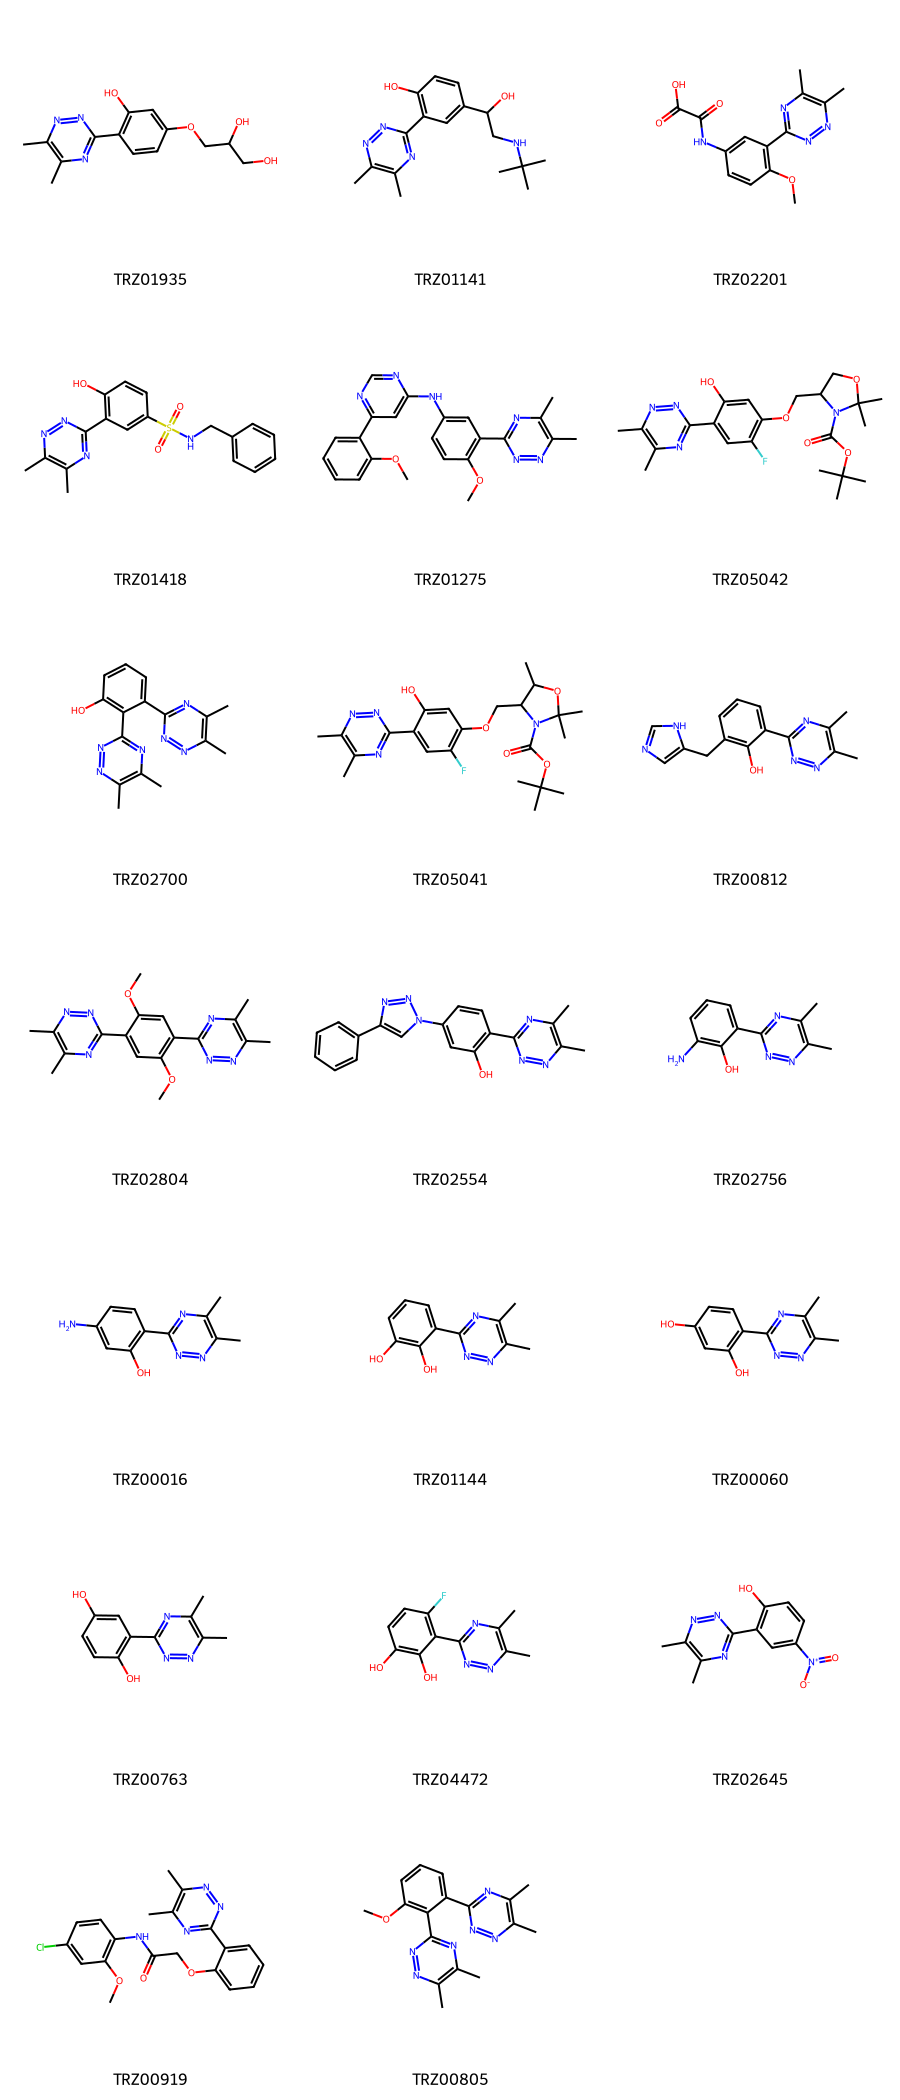

In [6]:
from rdkit.Chem import Draw
top20 = ranked_df.head(20)
# Converting SMILES to molecules
mols = [Chem.MolFromSmiles(s) for s in top20['SMILES']]

a = ranked_df['Triazine_ID'].tolist()
# Drawing grid of molecules
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,300), legends=a)
display(img)